In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
import seaborn as sns
# 忽略 DataScaleWarning 和 FutureWarning
warnings.filterwarnings('ignore', category=UserWarning, message='.*DataScaleWarning.*')
warnings.filterwarnings('ignore', category=FutureWarning)

# 您的其他代码...


# Set the random seed for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

# Load the dataset
file_path = 'Bitcoinclose.xlsx'  
data = pd.read_excel(file_path)

# Convert the 'date' column to datetime
data['date'] = pd.to_datetime(data['date'])

# Reverse the data to make it chronological (from old to new)
data = data[::-1].reset_index(drop=True)

# Fill missing values using forward fill (ffill) method
data.fillna(method='ffill', inplace=True)

# Use only the 'close' for prediction (univariate time series)
y = data['close'].values

# Normalize the target variable using MinMaxScaler
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Define the sliding window size
window_size = 3

# Prepare the data with a sliding window approach
def create_dataset(y_scaled, window_size):
    X, y = [], []
    for i in range(len(y_scaled) - window_size):
        X.append(y_scaled[i:i + window_size])
        y.append(y_scaled[i + window_size])
    return np.array(X), np.array(y)

X, y = create_dataset(y_scaled, window_size)

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define the GARCH model
model = arch_model(y_train.flatten(), vol='Garch', p=1, q=1,rescale=False)  # p=1, q=1 for a simple GARCH(1, 1) model
model_fit = model.fit(disp="off")

# Model evaluation on test data
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1))  # Rescale back to original prices
y_pred = model_fit.forecast(horizon=len(y_test), start=len(y_train)-1)

# GARCH model forecasted volatility
forecasted_volatility = y_pred.variance.values[-1, :]

# We use the predicted volatility as a representation of uncertainty in price predictions
# For simplicity, let's just predict the same as the last value of the training data
predictions = np.repeat(y_train[-1], len(y_test))

# Inverse transform the predictions back to the original scale
predictions_original = scaler_y.inverse_transform(predictions.reshape(-1, 1))

# Calculate additional evaluation metrics
mse = mean_squared_error(y_test_original, predictions_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, predictions_original)
mape = np.mean(np.abs((y_test_original - predictions_original) / y_test_original)) * 100
r2 = r2_score(y_test_original, predictions_original)




Mean Squared Error (MSE): 431732893.6473
Root Mean Squared Error (RMSE): 20778.1831
Mean Absolute Error (MAE): 18146.6840
Mean Absolute Percentage Error (MAPE): 86.1022
R² Score: -3.1671


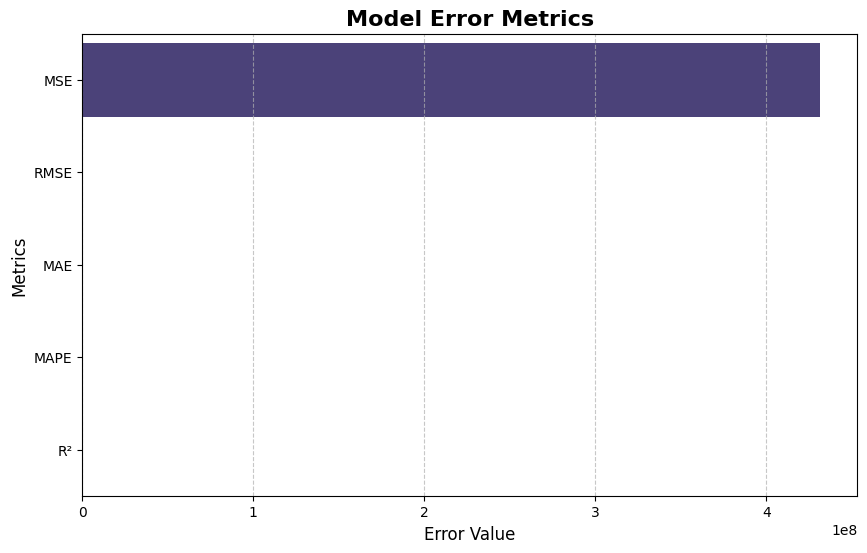

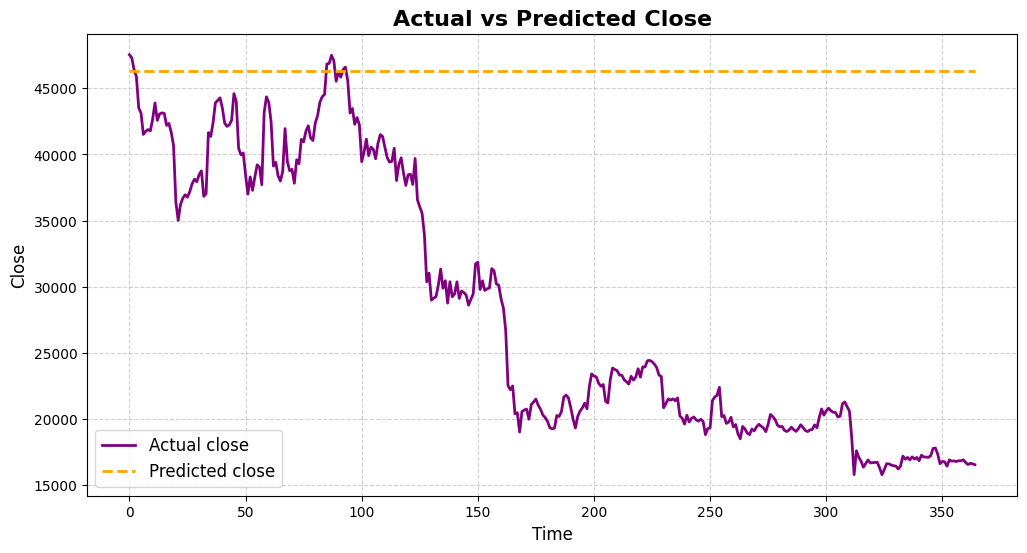

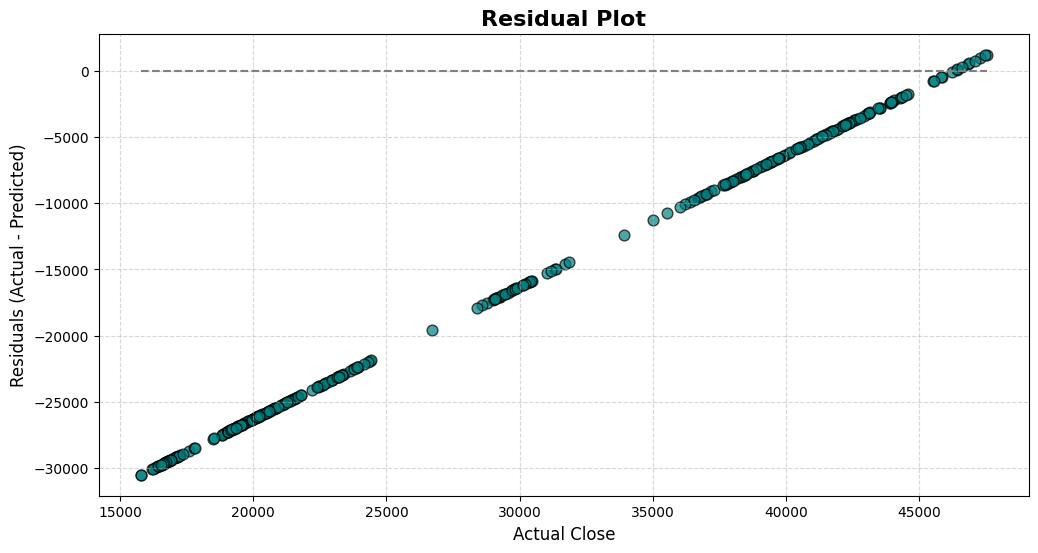

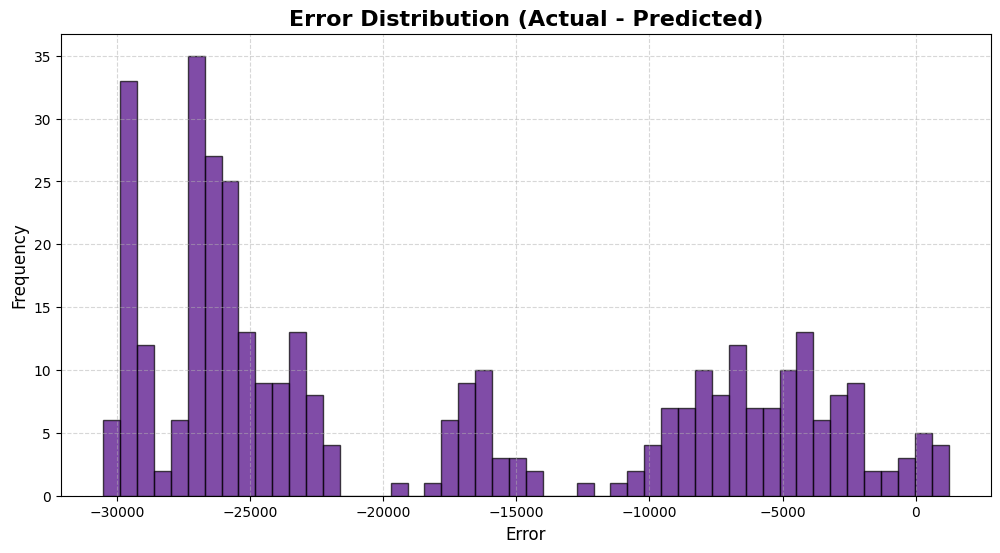

In [2]:
# Output the metrics
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}')
print(f'R² Score: {r2:.4f}')

# Visualization of Metrics (Bar Chart)
metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R²': r2}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(metrics.values()), y=list(metrics.keys()), palette='viridis')
plt.title('Model Error Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Error Value', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Visualization: Actual vs Predicted (Line Plot)
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label='Actual close', color='purple', linewidth=2)
plt.plot(predictions_original, label='Predicted close', color='orange', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Close', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Close', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Residual Plot
residuals = y_test_original - predictions_original
plt.figure(figsize=(12, 6))
plt.scatter(y_test_original, residuals, color='teal', edgecolor='black', alpha=0.7, s=60)
plt.hlines(y=0, xmin=y_test_original.min(), xmax=y_test_original.max(), color='gray', linestyle='--', linewidth=1.5)
plt.title('Residual Plot', fontsize=16, fontweight='bold')
plt.xlabel('Actual Close', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Error Distribution (Histogram)
errors = y_test_original - predictions_original
plt.figure(figsize=(12, 6))
plt.hist(errors, bins=50, color='indigo', edgecolor='black', alpha=0.7)
plt.title('Error Distribution (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()